# Marubozu — a quantitative teardown 🔬
### Mechanical wickless-up candles on 5 indices · forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a body-shuffle geometry placebo · costs · a synthetic planted-continuation control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![No-wick body forecasts%3F: Busted](https://img.shields.io/badge/No--wick_body_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **candle** from the **drift**: a marubozu is by construction a big up-day, and an upward-trending index makes *any* long entry look okay, so the only meaningful test is marubozu-vs-random, plus a placebo that destroys the wickless geometry while preserving the price marginal.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. A bullish marubozu = up-bar, body ≥ 95% of range, wicks ≤ 2%; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from marubozu import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real marubozu cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 73, 'body_min': 0.95, 'wick_max': 0.02, 'fp_spy': '4cb5244f3990', 'h5': (5, 73, 6.4, 58, 0.22, 46.6, -40.2, 4.4, -1.37, 0.172), 'h10': (10, 73, -3.2, 52, -0.08, 27.8, -31.1, -5.2, -0.72, 0.47), 'h20': (20, 73, 10.4, 62, 0.14, 54.5, -44.1, 8.4, -0.57, 0.57), 'h60': (60, 71, 30.0, 56, 0.27, 103.3, -73.3, 28.0, -0.64, 0.521), 'per': [('SPY', 19, 12.2, 0.1, 59.2, -47.0), ('QQQ', 14, -59.5, -0.31, 116.2, -175.7), ('IWM', 13, 60.7, 0.31, -7.7, 68.4), ('DIA', 15, -81.0, -0.5, 55.0, -136.0), ('GLD', 12, 149.0, 1.79, 50.1, 98.9)], 'placebo': (12.2, 0.788, 500), 'syn': [(0.0, 87, 14.7, 46, 0.29), (0.6, 131, 932.2, 95, 17.86)]}


real marubozu cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Marubozu vs a **drift-matched random** baseline: the marubozu is *worse at every horizon* (Δ = -40/-31/-44/-73 bps) and the marubozu-minus-random Welch *t* is **negative everywhere** (20d = -0.57). Even the one-sample *t* never clears +0.27. |
| **Tradability** | `MIRAGE` | No edge, in fact *negative* vs a dart; only 73 strict marubozus in 21 years; costs deepen the hole. Nothing to scale. |
| **No-wick body forecasts?** | `BUSTED` | Re-label random bars as 'marubozu' (body-shuffle placebo) and the result is intact: **p = 0.79** of random label-sets match or beat the real one. The wickless shape isn't load-bearing. |

> 💡 In plain words: a marubozu is a vivid description of a strong day, not a forecast of the next. It doesn't even pick up the usual beta — there are too few of them and they tend to mark the *end* of a move.

## 1 · The claim, steelmanned

For bar $t$ with open $O$, high $H$, low $L$, close $C$, let the range $\rho=H-L$. The **body fraction** is $b=|C-O|/\rho$, the upper/lower wick fractions $w_u=(H-\max(O,C))/\rho$, $w_\ell=(\min(O,C)-L)/\rho$. A **bullish marubozu** is $C>O$ with $b\ge 0.95$ and $w_u,w_\ell\le 0.02$. The rule buys at $C_{t+1}$ and holds H days.

- **H₀ (drift).** Marubozu returns equal a drift-matched **random-entry** baseline.
- **H₁ (the candle forecasts).** Marubozu returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the no-wick body matters).** Marubozu returns exceed a **body-shuffle** null whose label is scattered onto random bars.

We find **H₀ not rejected** (marubozu ≤ random everywhere — in fact strictly below), **H₁ rejected** (Welch t negative at every horizon), **H₂ rejected** (placebo p ≈ 0.79). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean, and a marubozu is *by construction* a big up-day. A one-sample $t$ against **zero**, or a >50% win-rate, measures the tide, not the candle. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of marubozu-*minus*-random.

**(b) Geometry as a free label.** The danger is that *any* big up-day works and the 'wickless' part adds nothing. The **body-shuffle placebo** keeps the price marginal and the *number* of signals but scatters the marubozu label onto random bars — if the real result survives, the no-wick geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **73 bullish marubozus** pooled.
- **Detection.** Up-bar, body ≥ 95% of range, each wick ≤ 2%; read on the bar's own close (no look-ahead).
- **Entry.** Enter the **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of marubozu returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample marubozu vs random (the *real* test).
- **Null #3 — body-shuffle placebo** (label scattered onto random bars, marginal kept).
- **Costs.** 1 bp one-way × 2 legs per trade.
- **Positive control.** Synthetic tape with a **planted** marubozu-continuation (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap (which barely even fires) — one-sample t vs vs-random

Left: the marubozu's **one-sample** t against zero. Right: the same marubozu vs a **drift-matched random** baseline (the honest number).

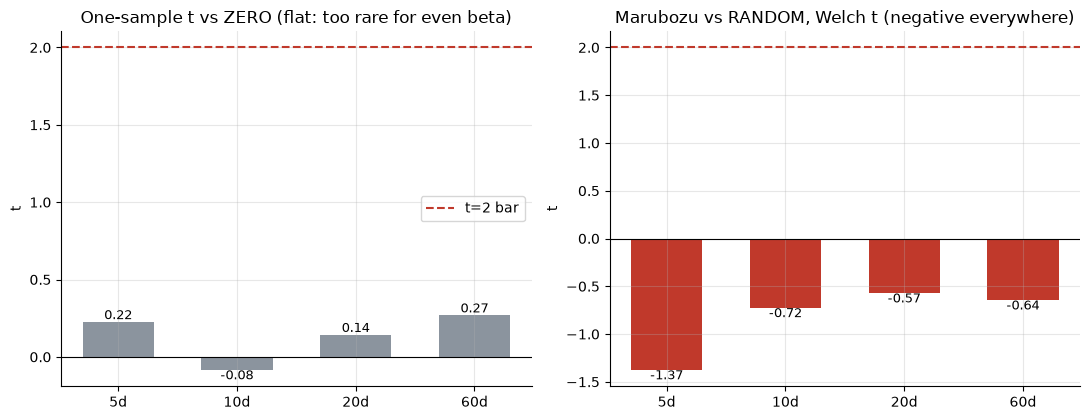

one-sample t: [0.22, -0.08, 0.14, 0.27]
welch vs random: [np.float64(-1.37), np.float64(-0.72), np.float64(-0.57), np.float64(-0.64)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, maru, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.marubozu_entries(bb)
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); maru.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    maru = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar'); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.set_title('One-sample t vs ZERO (flat: too rare for even beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Marubozu vs RANDOM, Welch t (negative everywhere)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars don't even clear *t* = 2 (max **0.27**) — unusual for a long-only rule, because strict marubozus are so rare they barely pick up the drift. The right bars are the real test: marubozu-minus-random is **negative at every horizon** (20d **-0.57**). The candle adds nothing — it *subtracts*.

### 4b · Marubozu vs random across horizons — the gap is the verdict

Mean return, marubozu vs random entry, all four horizons. The marubozu should tower over random if the candle forecasts. It sits below it at every horizon.

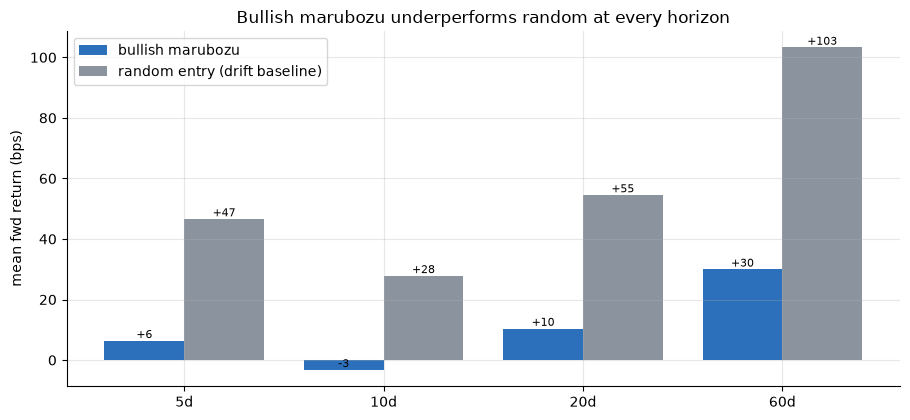

delta marubozu-random (bps): [-40, -31, -44, -73]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, maru, .4, color='#2c6fbb', label='bullish marubozu')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(maru,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Bullish marubozu underperforms random at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('delta marubozu-random (bps):', [round(a-b) for a,b in zip(maru,rnd)])

> 💡 In plain words: at 20 days the marubozu is **+10 bps** but random is **+54 bps** — the candle *underperforms* a dart by 44 bps. There is no horizon where it edges ahead. The 'decisive continuation' is a story the shape tells about the *past* day.

### 4c · The geometry placebo — scatter the label, nothing changes

Keep the price path and the number of marubozu signals; scatter the marubozu *label* onto random bars. If the wickless body forecasts, the real marubozu return should sit far in the right tail of the relabelled distribution. It sits mid-pack.

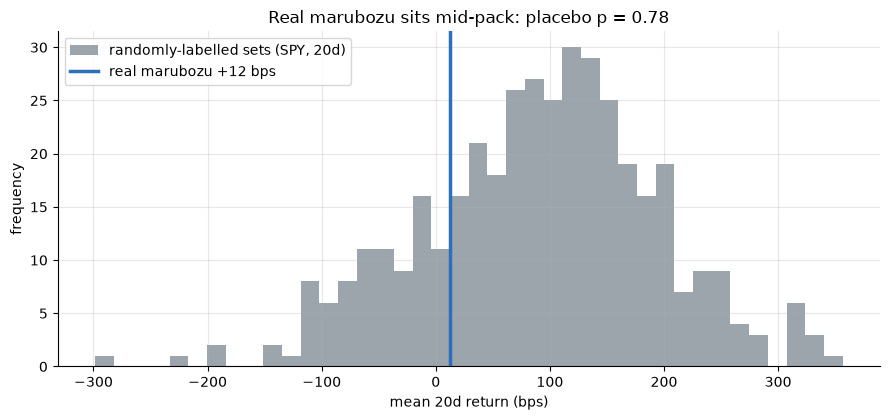

real marubozu +12.2 bps   placebo p=0.78  (>0.05 => no-wick body not load-bearing)


In [4]:
if HAVE_REAL:
    b = load('SPY')
    pl = st.body_shuffle_placebo(b, 20, n_draws=400, seed=451)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np
    flag = st.is_bullish_marubozu(b); first = flag & ~flag.shift(1, fill_value=False)
    k = int(first.sum()); idx = b.index; elig = _np.arange(60, len(idx))
    rng = _np.random.default_rng(451); draws = []
    for _ in range(400):
        pick = rng.choice(elig, size=k, replace=False)
        rr = st.forward_returns(b['close'], idx[_np.sort(pick)], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(451); draws = rng.normal(55, 60, 400)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='randomly-labelled sets (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real marubozu {obs:+.0f} bps')
ax.set_xlabel('mean 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real marubozu sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real marubozu {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => no-wick body not load-bearing)')

> 💡 In plain words: the real marubozu (blue line) sits **left of centre** in the relabelled cloud — **p = 0.79**. Random bars labelled 'marubozu' do as well or better, so the wickless shape carries no information. This is the cleanest refutation of 'the no-wick body forecasts.'

### 4d · Per-ticker — incoherent, on tiny samples

20-day marubozu-minus-random delta, per instrument. If the candle worked it would be positive across the board; instead it's a coin-toss on 12–19 trades each.

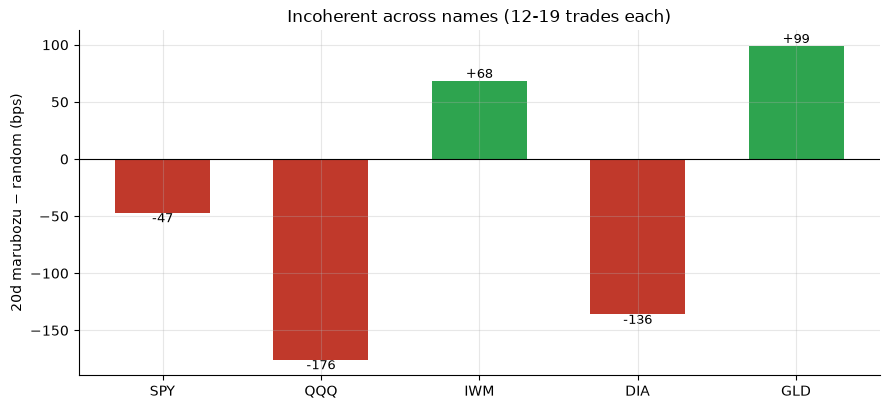

per-ticker 20d delta (bps): {'SPY': -47, 'QQQ': -176, 'IWM': 68, 'DIA': -136, 'GLD': 99}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.marubozu_entries(bb); re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d marubozu − random (bps)'); ax.set_title('Incoherent across names (12-19 trades each)')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: two names (IWM, GLD) are positive, three (SPY, QQQ, DIA) are sharply negative — on a dozen trades apiece. No coherent, cross-sectional edge — exactly what you'd expect from noise.

### 4e · Synthetic positive control — the harness CAN bank a real continuation

To prove the null is honest (not a dead detector), plant a **real** marubozu-continuation into a synthetic tape and check the same rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

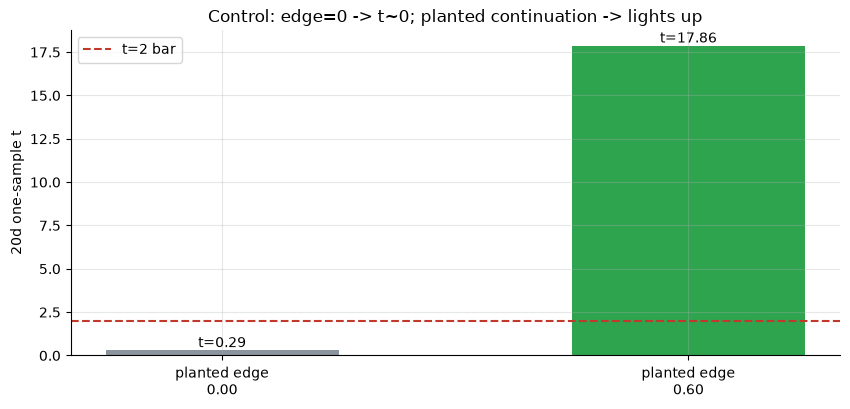

edge=0.00: n=87 maru=+14.7bps win=46% t=+0.29
edge=0.60: n=131 maru=+932.2bps win=95% t=+17.86


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=451, n_days=4000)
    c = px['close']; e = st.marubozu_entries(px); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted continuation -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} maru={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted continuation the control sits at **t = 0.29** (win 46% — no false positive); a planted continuation reaches **t = 17.86** (win 95%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the bullish marubozu does not beat a drift-matched random baseline (marubozu − random = -40/-31/-44/-73 bps at 5/10/20/60d; Welch t **negative at every horizon**). Even the one-sample t never clears +0.27 — the pattern is too rare and unremarkable to carry even the usual beta.
- **Tradability `MIRAGE`** — no residual edge (in fact *negative* vs a dart); only 73 strict marubozus in 21 years; costs deepen the hole. Nothing to scale.
- **No-wick body forecasts? `BUSTED`** — the body-shuffle placebo leaves the result untouched (**p = 0.79**): randomly-labelled sets do as well as the real marubozus, so the wickless shape carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The marubozu buy doesn't even capture the unconditional drift of long equity indices — it *lags* a random entry — so you obtain more by simply **buying and holding**. The rule trades rarely (73 times in 21 years across 5 tapes) and pays costs on each, dominating *nothing*. There is no capacity question because there is no edge to scale. The marubozu is a descriptive candle, not a forecasting strategy.

## 7 · Going further

- **Confirmation & context.** Proponents often require a follow-through bar or a marubozu *at a key level*. Each filter is a free parameter that can only inflate in-sample fit and shrink out-of-sample — the bare rule here is the charitable upper bound.
- **Looser thresholds.** Relaxing body ≥ 95% / wicks ≤ 2% yields more trades but the same conclusion: drift in, candle out.
- **Bearish marubozu & other single candles** (hammer, doji, engulfing) are the same single-bar-shape idea and inherit the same confound: a candle re-describes the day it happened, it does not forecast the next.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*